In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import io

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset_kelulusan_mahasiswa.csv to dataset_kelulusan_mahasiswa.csv


In [ ]:
data = pd.read_csv(io.BytesIO(uploaded['dataset_kelulusan_mahasiswa.csv']))

In [ ]:
data

,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren,Kategori Kehadiran
0,3.87,5,1,Ya,13,1,3.299231,2.66,0.57,Sedang
1,3.65,5,1,Tidak,12,0,3.069167,3.56,1.21,Rendah
2,3.57,2,2,Tidak,11,1,2.955455,2.89,-0.59,Tinggi
3,3.96,0,1,Tidak,12,0,3.230833,2.63,-1.34,Rendah
4,2.27,0,0,Ya,9,1,3.066667,2.22,-1.14,Sedang
...,...,...,...,...,...,...,...,...,...,...
99995,3.70,1,2,Tidak,8,1,2.893750,2.74,0.33,Rendah
99996,2.03,3,1,Ya,8,1,2.806250,2.38,-1.08,Tinggi
99997,2.12,3,1,Ya,13,1,3.043846,2.10,-1.26,Tinggi
99998,2.29,5,0,Tidak,13,0,3.048462,3.64,0.02,Rendah


In [ ]:
X = data.iloc[:, :-1]
X

,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren
0,3.87,5,1,Ya,13,1,3.299231,2.66,0.57
1,3.65,5,1,Tidak,12,0,3.069167,3.56,1.21
2,3.57,2,2,Tidak,11,1,2.955455,2.89,-0.59
3,3.96,0,1,Tidak,12,0,3.230833,2.63,-1.34
4,2.27,0,0,Ya,9,1,3.066667,2.22,-1.14
...,...,...,...,...,...,...,...,...,...
99995,3.70,1,2,Tidak,8,1,2.893750,2.74,0.33
99996,2.03,3,1,Ya,8,1,2.806250,2.38,-1.08
99997,2.12,3,1,Ya,13,1,3.043846,2.10,-1.26
99998,2.29,5,0,Tidak,13,0,3.048462,3.64,0.02


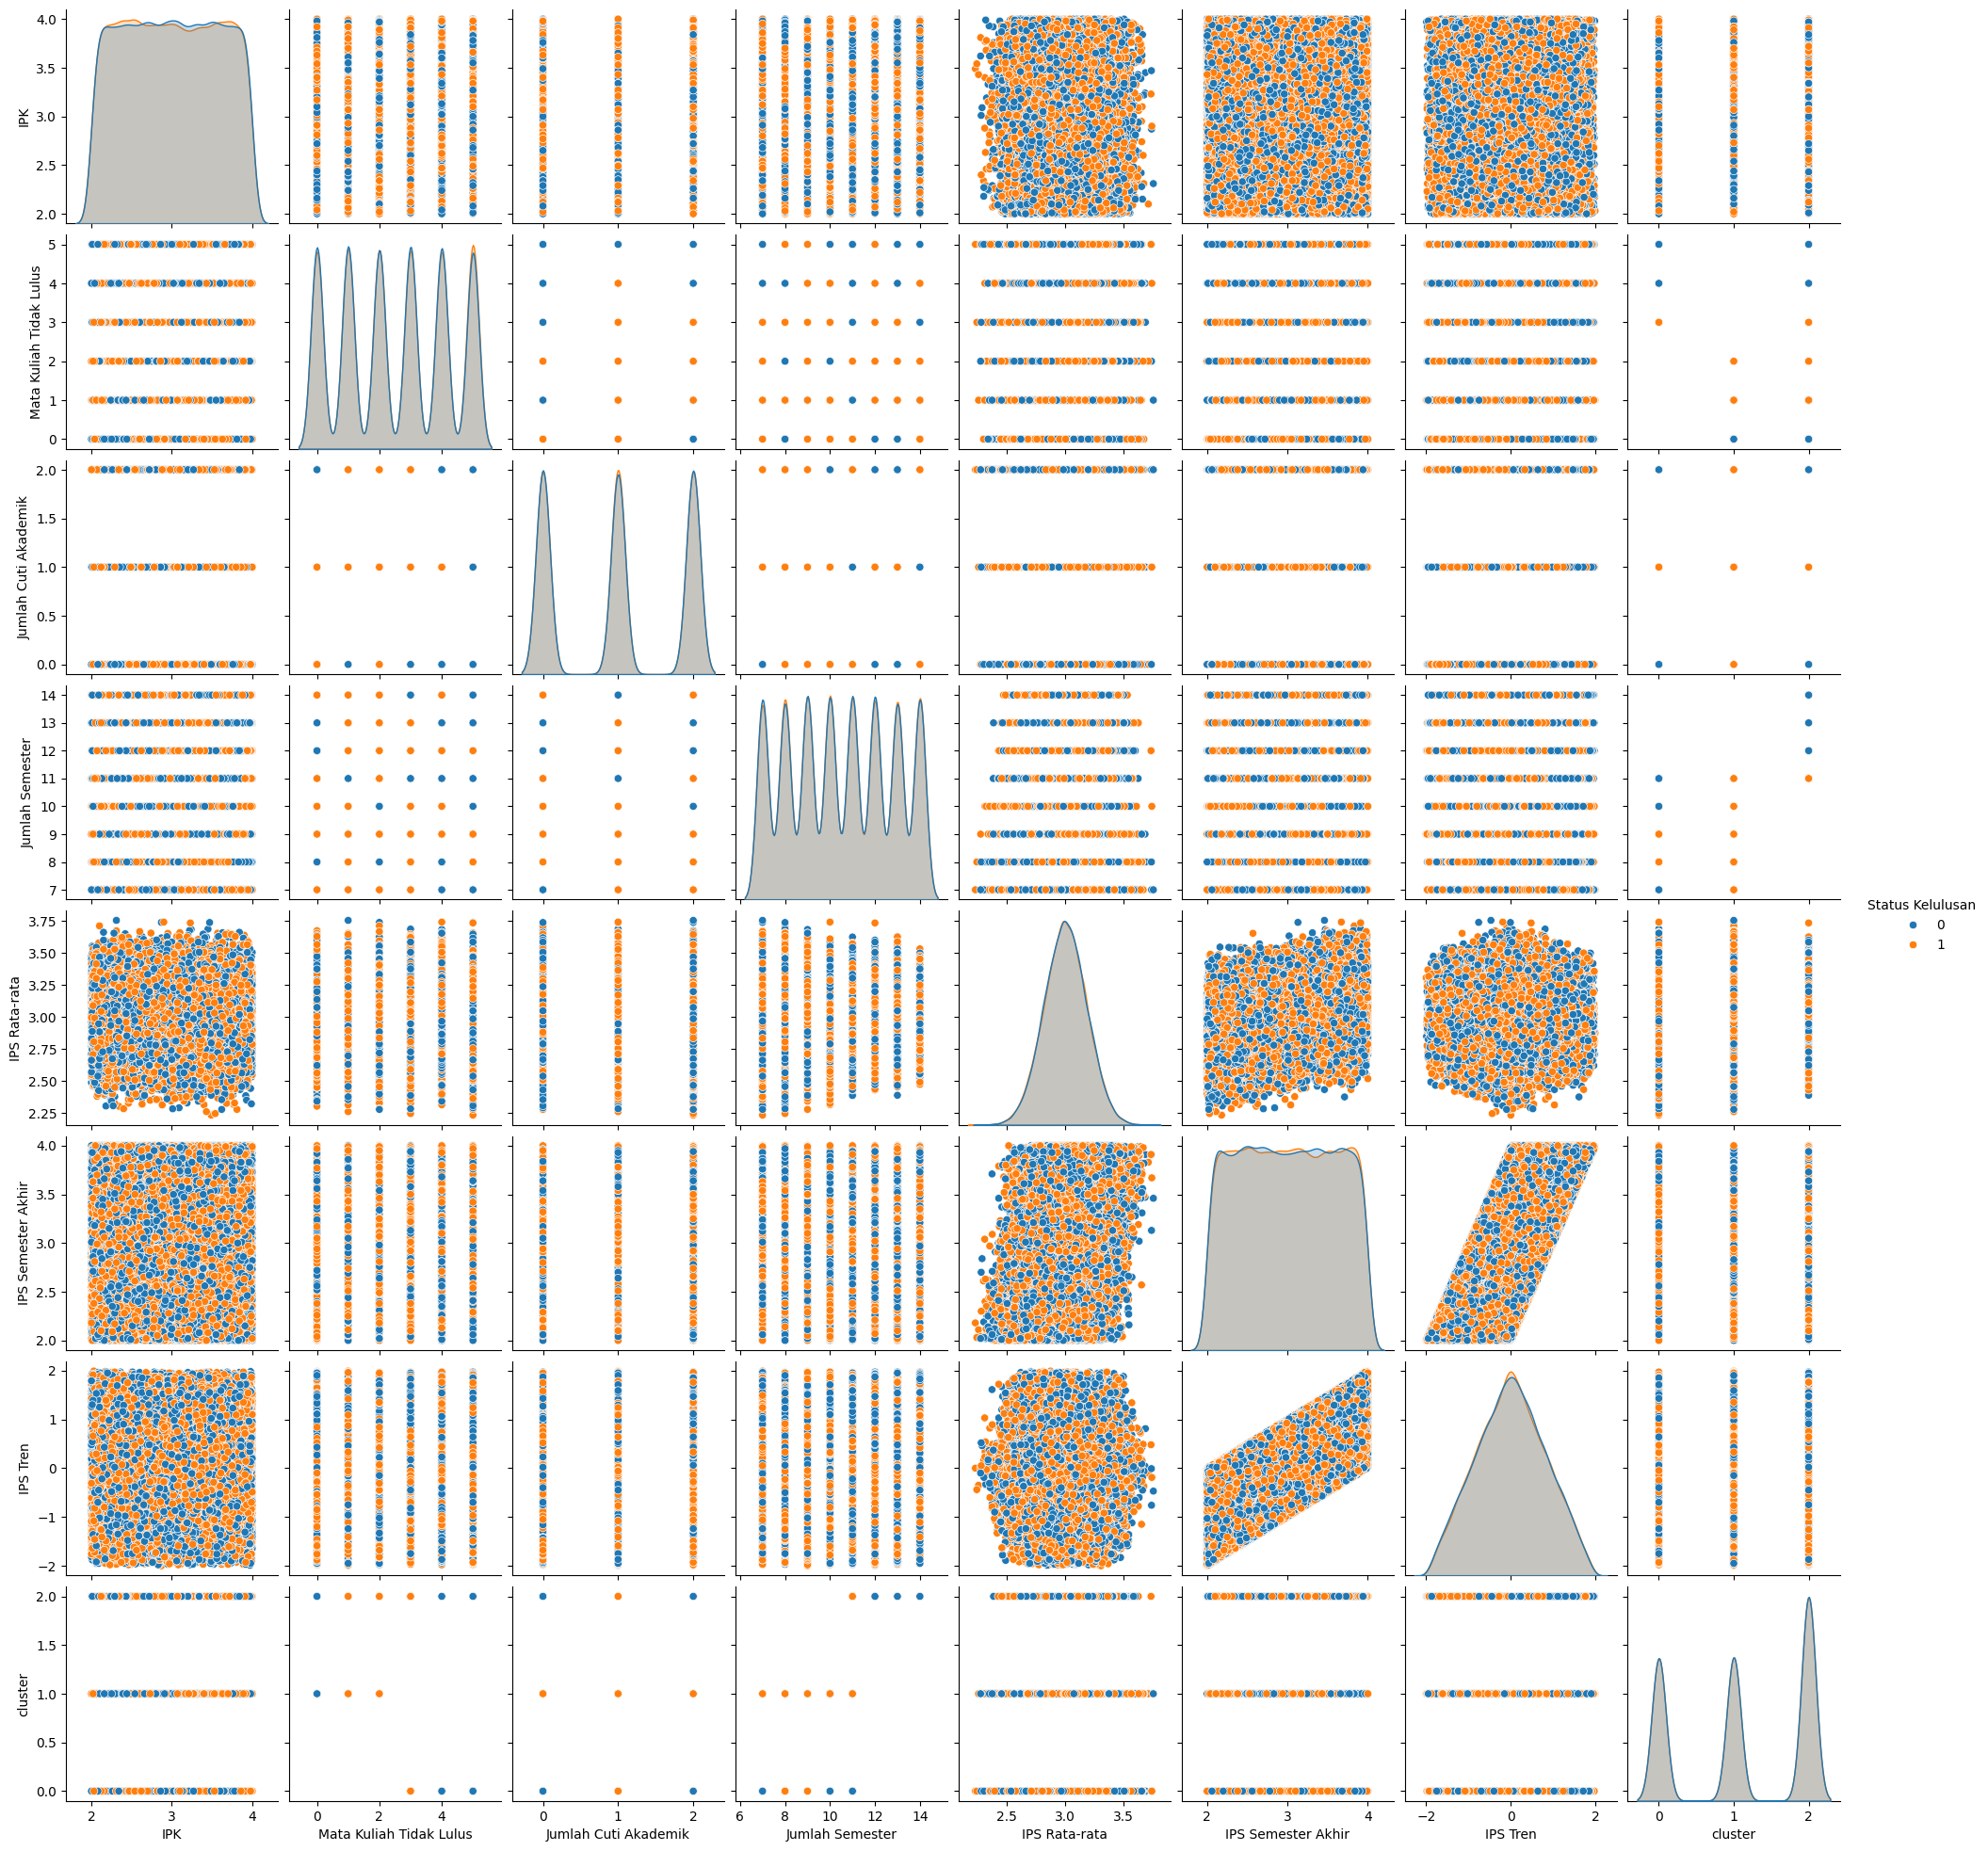

In [ ]:
sns.pairplot(data, hue="Status Kelulusan")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
le = LabelEncoder()
X['Pekerjaan Sambil Kuliah'] = le.fit_transform(X['Pekerjaan Sambil Kuliah'])

WCSS = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
  kmeans.fit(X)
  WCSS.append(kmeans.inertia_)
WCSS

[1066694.7299043175,
 670454.7864500871,
 548095.8647292393,
 445427.74946398253,
 409721.09737311676,
 376566.973640921,
 360775.9241426116,
 345162.4777734534,
 334831.23934780154,
 326123.71232331987]

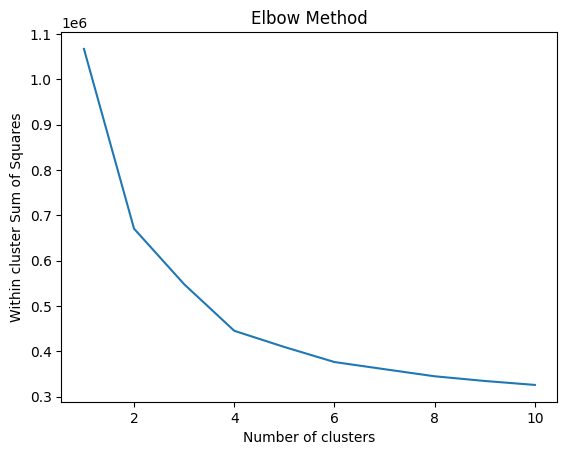

In [ ]:
plt.plot(range(1, 11), WCSS)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Within cluster Sum of Squares')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X)

In [ ]:
y_kmeans

array([2, 2, 2, ..., 2, 2, 2], dtype=int32)

In [ ]:
davies_bouldin_score(X, y_kmeans)

np.float64(1.294163433252779)

In [ ]:
data['cluster'] = y_kmeans
data

,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren,Kategori Kehadiran,cluster
0,3.87,5,1,Ya,13,1,3.299231,2.66,0.57,Sedang,2
1,3.65,5,1,Tidak,12,0,3.069167,3.56,1.21,Rendah,2
2,3.57,2,2,Tidak,11,1,2.955455,2.89,-0.59,Tinggi,2
3,3.96,0,1,Tidak,12,0,3.230833,2.63,-1.34,Rendah,2
4,2.27,0,0,Ya,9,1,3.066667,2.22,-1.14,Sedang,1
...,...,...,...,...,...,...,...,...,...,...,...
99995,3.70,1,2,Tidak,8,1,2.893750,2.74,0.33,Rendah,1
99996,2.03,3,1,Ya,8,1,2.806250,2.38,-1.08,Tinggi,0
99997,2.12,3,1,Ya,13,1,3.043846,2.10,-1.26,Tinggi,2
99998,2.29,5,0,Tidak,13,0,3.048462,3.64,0.02,Rendah,2


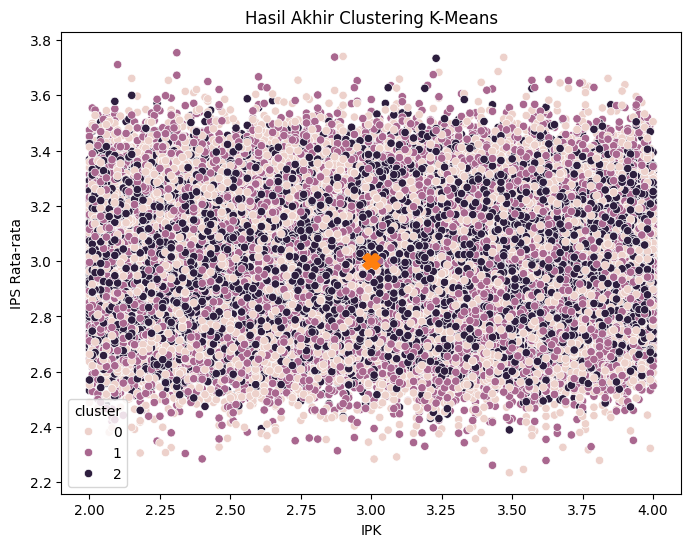

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x="IPK",
    y="IPS Rata-rata",
    hue="cluster"
)

# Centroid
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 6],
    s=120,
    marker="X"
)
plt.title("Hasil Akhir Clustering K-Means")
plt.xlabel("IPK")
plt.ylabel("IPS Rata-rata")
plt.show()

In [ ]:
data.head(150)

,IPK,Mata Kuliah Tidak Lulus,Jumlah Cuti Akademik,Pekerjaan Sambil Kuliah,Jumlah Semester,Status Kelulusan,IPS Rata-rata,IPS Semester Akhir,IPS Tren,Kategori Kehadiran,cluster
0,3.87,5,1,Ya,13,1,3.299231,2.66,0.57,Sedang,2
1,3.65,5,1,Tidak,12,0,3.069167,3.56,1.21,Rendah,2
2,3.57,2,2,Tidak,11,1,2.955455,2.89,-0.59,Tinggi,2
3,3.96,0,1,Tidak,12,0,3.230833,2.63,-1.34,Rendah,2
4,2.27,0,0,Ya,9,1,3.066667,2.22,-1.14,Sedang,1
...,...,...,...,...,...,...,...,...,...,...,...
145,2.49,0,0,Tidak,11,0,3.100000,3.58,0.84,Sedang,1
146,2.58,4,0,Tidak,10,0,3.058000,2.56,0.53,Rendah,0
147,2.51,3,0,Ya,11,0,3.118182,3.38,-0.58,Tinggi,2
148,2.66,4,0,Ya,11,0,2.960000,3.85,0.25,Sedang,0
